In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_mfcc(df, segmented_dir, all_categories, n_mfcc=13, hop_length=512, sr=16000):
    segmented_dir = Path(segmented_dir)
    mfcc_list = []
    labels = []
    
    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, _ = librosa.load(file, sr=sr)
            n_fft = min(2048, len(y))
            mfcc = librosa.feature.mfcc(y=y, 
                                        sr=sr, 
                                        n_mfcc=n_mfcc, 
                                        n_fft=n_fft, 
                                        hop_length=hop_length)
            # mfcc_db = librosa.power_to_db(mfcc**2)
            # mfcc_list.append(mfcc_db)
            mfcc_list.append(mfcc)
            labels.append(f.label)
        
    X = np.array(mfcc_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [3]:
train_csv_path = 'kaggle_meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

In [4]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [5]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('kaggle_data', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

Import data for model

In [6]:
X, y = create_mfcc(train_df, 'kaggle_segmented', musical_instruments)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

1847it [03:52,  7.94it/s]


Plot MFCC

In [7]:
def plot_mfcc(X, i):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.show()

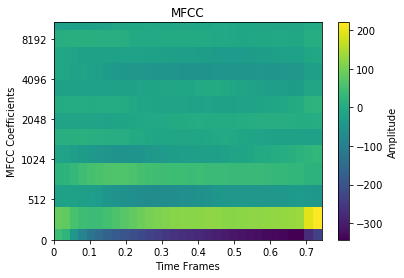

In [8]:
plot_mfcc(X_train, 5)

CNN model

In [9]:
# cnn = models.Sequential([
#     layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(len(musical_instruments), activation='softmax')
# ])

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(musical_instruments), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 13, 32, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 13, 32, 32)        128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 7, 16, 32)         0         
_________________________________________________________________
dropout (Dropout)            (None, 7, 16, 32)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 7, 16, 64)         18496     
_________________________________________________________________
batch_normalization_1 (Batch (None, 7, 16, 64)         256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 8, 64)          0

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
150/150 [==============================] - 2s 14ms/step - loss: 1.9513 - accuracy: 0.3997 - val_loss: 1.2580 - val_accuracy: 0.5997
Epoch 2/100
150/150 [==============================] - 2s 13ms/step - loss: 1.3406 - accuracy: 0.5790 - val_loss: 1.0144 - val_accuracy: 0.6664
Epoch 3/100
150/150 [==============================] - 2s 13ms/step - loss: 1.1506 - accuracy: 0.6389 - val_loss: 1.0114 - val_accuracy: 0.6664
Epoch 4/100
150/150 [==============================] - 2s 13ms/step - loss: 1.0312 - accuracy: 0.6724 - val_loss: 0.8766 - val_accuracy: 0.7056
Epoch 5/100
150/150 [==============================] - 2s 13ms/step - loss: 0.9205 - accuracy: 0.7035 - val_loss: 0.7376 - val_accuracy: 0.7706
Epoch 6/100
150/150 [==============================] - 2s 13ms/step - loss: 0.8475 - accuracy: 0.7275 - val_loss: 0.6499 - val_accuracy: 0.7690
Epoch 7/100
150/150 [==============================] - 2s 13ms/step - loss: 0.7888 - accuracy: 0.7498 - val_loss: 0.5746 - val_accuracy:

Evaluate CNN

In [11]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_mfcc_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .80

Accuracy: 0.914609739826551

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.99      0.97      0.98        98
       Bass_drum       0.88      0.93      0.90        15
           Cello       0.88      1.00      0.93        21
        Clarinet       0.94      0.78      0.85        37
         Cowbell       0.86      0.90      0.88        63
     Double_bass       0.98      0.87      0.92        92
  Electric_piano       0.93      0.91      0.92       322
           Flute       0.88      0.95      0.92       167
    Glockenspiel       0.87      0.92      0.89       151
       Harmonica       1.00      0.96      0.98        28
          Hi-hat       0.93      0.71      0.81        70
            Oboe       0.94      0.89      0.92        95
       Saxophone       0.93      0.93      0.93        15
      Tambourine       1.00      0.86      0.92        21
         Trumpet       0.83      0.94      0.89       107
Violin_or_fiddle  

Save CNN

In [12]:
# cnn.save('cnn_mfcc_model.h5')